<a href="https://colab.research.google.com/github/vyakhyaagoyal/DL_Lab_V/blob/main/Vyakhya_Goyal_Lab_06_CNN_Operations_From_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lab-06: Implementation of Convolution, Padding, Stride, and Pooling Operations from Scratch**

### Deep Learning Laboratory — Fifth Semester, Session 2026–27
**Department of Electronics Engineering, Ramdeobaba University, Nagpur**  
**Prepared by: Prof. V. R. Gupta, Course Coordinator**

---

## Aim
To implement two-dimensional convolution, valid and same padding, variable stride, max pooling, and average pooling using NumPy; verify output-dimension calculations; and visualize the effect of edge-detection, sharpening, and blurring filters on image feature maps.

### Mapped Course Outcomes
- **CO3:** Design and implement convolutional neural network architectures and analyze the effect of architectural parameters on model performance.
- **CO6:** Analyze and optimize key architectural and training parameters to enhance the performance and generalization of deep learning models.

> **Important:** In deep-learning libraries, the operation commonly called *convolution* is usually implemented as **cross-correlation** (the filter is not flipped). This notebook follows the CNN convention.

## Learning Outcomes
After completing this experiment, you should be able to:

1. implement 2D convolution/cross-correlation from first principles using NumPy;
2. calculate output dimensions for different filter sizes, padding values, and strides;
3. implement zero padding and support `valid` / `same` convolution behavior;
4. generalize convolution to an input volume with multiple channels and a bank of filters;
5. implement max pooling and average pooling from scratch;
6. combine convolution, ReLU, and pooling into a basic CNN feature-extraction block; and
7. analyze how filter type, filter size, padding, stride, and pooling affect the feature maps.

## Table of Contents
1. [Packages and Supporting Files](#packages)
2. [Standard CNN Notation](#notation)
3. [Output-Dimension Formula](#dimensions)
4. [Part A — Basic 2D Convolution](#part-a)
5. [Part B — Zero Padding and Variable Stride](#part-b)
6. [Part C — General CNN Convolution](#part-c)
7. [Part D — Max and Average Pooling](#part-d)
8. [Part E — Combine Convolution, ReLU, and Pooling](#part-e)
9. [Part F — Image Filter Experiments](#part-f)
10. [Part G — Parameter Experiments and Analysis](#part-g)
11. [Final Public-Test Check](#final-test)
12. [Submission Requirements](#submission)

<a name="packages"></a>
## 1 — Packages and Supporting Files

Keep the following files in the **same Colab working directory** as this notebook:

- `cnn_utils_lab06.py`
- `testCases_lab06.py`
- `public_tests_lab06.py`

The utility file contains only visualization/demo-image helpers. The test files contain deterministic test inputs and public correctness checks.

### Restrictions for this experiment
You **must not** use ready-made convolution or pooling operations such as:

- `scipy.signal.convolve2d`, `scipy.signal.correlate2d`
- OpenCV filtering functions such as `cv2.filter2D`
- TensorFlow/Keras `Conv2D`, `MaxPooling2D`, `AveragePooling2D`
- PyTorch `torch.nn.Conv2d`, `MaxPool2d`, `AvgPool2d`

You **may** use NumPy for array creation, slicing, zero padding, multiplication, summation, maximum, and mean operations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from cnn_utils_lab06 import (
    create_demo_image,
    normalize_for_display,
    show_image,
    show_feature_volume,
    print_volume_shape,
)
from testCases_lab06 import *
from public_tests_lab06 import *

np.set_printoptions(precision=3, suppress=True)
plt.rcParams['figure.figsize'] = (6, 5)
print("Supporting files imported successfully.")

Supporting files imported successfully.


<a name="notation"></a>
## 2 — Standard CNN Notation Used in This Lab

Use the following notation consistently in calculations, comments, observations, and viva answers.

| Symbol | Meaning |
|---|---|
| $H_{\mathrm{in}}, W_{\mathrm{in}}, C_{\mathrm{in}}$ | input height, width, and channels |
| $H_{\mathrm{out}}, W_{\mathrm{out}}, C_{\mathrm{out}}$ | output height, width, and channels |
| $F$ | convolutional filter/kernel spatial size |
| $P$ | zero-padding size |
| $S$ | convolution stride |
| $K$ | number of convolutional filters |
| $F_{\mathrm{pool}}$ | pooling-window size |
| $S_{\mathrm{pool}}$ | pooling stride |

The theoretical representation of an image or feature volume is always:

$$\boxed{H\times W\times C}$$

For an input volume $H_{\mathrm{in}}\times W_{\mathrm{in}}\times C_{\mathrm{in}}$, each CNN filter must span the full input depth:

$$F\times F\times C_{\mathrm{in}}.$$

If there are $K$ filters, then:

$$\boxed{C_{\mathrm{out}}=K}.$$

<a name="dimensions"></a>
## 3 — Output-Dimension Formula

For convolution with filter size $F$, padding $P$, and stride $S$:

$$
H_{\mathrm{out}}=
\left\lfloor\frac{H_{\mathrm{in}}+2P-F}{S}\right\rfloor+1
$$

$$
W_{\mathrm{out}}=
\left\lfloor\frac{W_{\mathrm{in}}+2P-F}{S}\right\rfloor+1
$$

and if $K$ filters are used:

$$C_{\mathrm{out}}=K.$$

### Valid convolution
$$P=0.$$

### Same convolution used in this lab
For **odd $F$ and $S=1$**:

$$P=\frac{F-1}{2},$$

so $H_{\mathrm{out}}=H_{\mathrm{in}}$ and $W_{\mathrm{out}}=W_{\mathrm{in}}$.

> In this introductory lab, use `padding="same"` with **odd-sized filters and stride 1**. For other cases, pass an explicit integer padding value $P$.

### Warm-up: Predict the shape before running code
For each case below, calculate $H_{\mathrm{out}}\times W_{\mathrm{out}}\times C_{\mathrm{out}}$ manually.

1. Input $32\times32\times3$, $F=3$, $P=1$, $S=1$, $K=16$
2. Input $28\times28\times8$, $F=5$, $P=0$, $S=1$, $K=10$
3. Input $64\times64\times3$, $F=3$, $P=1$, $S=2$, $K=32$

Write your answers here before proceeding.

In [4]:
# STUDENT RESPONSE
#Case 1: 32 × 32 × 16
#Case 2: 24 × 24 × 10
#Case 3: 32 × 32 × 32

<a name="part-a"></a>
# 4 — Part A: Basic 2D Convolution from Scratch

We begin with the simplest case:

- one 2D input matrix;
- one 2D filter mask;
- $P=0$ (`valid`);
- $S=1$.

For each valid spatial position, extract an $F\times F$ window, perform element-wise multiplication with the filter mask, and sum all products.

### Exercise 1 — `conv2d_basic`
Complete the function without using any ready-made convolution routine.

In [6]:
def conv2d_basic(X, filter_mask):
    """
    Perform basic 2D CNN cross-correlation with P=0 and S=1.

    Parameters
    ----------
    X : np.ndarray, shape (H_in, W_in)
        2D input.
    filter_mask : np.ndarray, shape (F, F)
        Square spatial filter.

    Returns
    -------
    Z : np.ndarray, shape (H_out, W_out)
        Output feature map.
    """
    # START CODE HERE
    H, W = X.shape
    F = filter_mask.shape[0]

    H_out = H - F + 1
    W_out = W - F + 1

    Z = np.zeros((H_out, W_out))

    for i in range(H_out):
      for j in range(W_out):
        Z[i, j] = np.sum(X[i:i+F, j:j+F] * filter_mask)


    # END CODE HERE
    return Z

### Manual numerical verification
Use the test case below. Before running your function, manually calculate at least the **first two output values**.

In [9]:
X_small, filter_small = conv2d_basic_test_case()
print("X =", X_small)
print("filter_mask =", filter_small)
print("Expected output dimensions:", (X_small.shape[0]-filter_small.shape[0]+1,
                                        X_small.shape[1]-filter_small.shape[1]+1))

X = [[1. 2. 0. 1.]
 [3. 1. 2. 2.]
 [0. 1. 3. 1.]
 [2. 2. 1. 0.]]
filter_mask = [[ 1.  0.]
 [ 0. -1.]]
Expected output dimensions: (3, 3)


In [10]:
# Run after completing conv2d_basic
Z_basic = conv2d_basic(X_small, filter_small)
print("Z_basic =", Z_basic)
conv2d_basic_test(conv2d_basic)

Z_basic = [[ 0.  0. -2.]
 [ 2. -2.  1.]
 [-2.  0.  3.]]
✓ conv2d_basic: All tests passed.


### Checkpoint 1
Answer briefly:

- What does one value in `Z_basic` represent?
- Why is the output smaller than the input?
- If $F$ increases while $P=0$ and $S=1$, what happens to $H_{\mathrm{out}}$ and $W_{\mathrm{out}}$?

<a name="part-b"></a>
# 5 — Part B: Zero Padding and Variable Stride

Padding allows the filter to process locations close to the image boundary. Stride controls how far the filter moves after each computation.

## Exercise 2 — `zero_pad`
Write a function that adds $P$ rows/columns of zeros around the spatial boundary.

Your function must support:

- a 2D array with shape $(H,W)$; and
- a 3D volume with shape $(H,W,C)$ **without padding the channel axis**.

In [12]:
def zero_pad(X, P):
    """
    Add zero padding of size P around height and width dimensions.

    Parameters
    ----------
    X : np.ndarray
        Shape (H, W) or (H, W, C).
    P : int
        Number of zero rows/columns added to each spatial side.

    Returns
    -------
    X_pad : np.ndarray
        Zero-padded array.
    """
    # START CODE HERE
    if X.ndim == 2:
      X_pad = np.pad(X, ((P, P), (P, P)), mode='constant')
    else:
        X_pad = np.pad(X, ((P, P), (P, P), (0, 0)), mode='constant')


    # END CODE HERE
    return X_pad

In [13]:
# Test Exercise 2
X_pad_case, P_case = zero_pad_test_case()
X_padded = zero_pad(X_pad_case, P_case)
print("Original shape:", X_pad_case.shape)
print("Padded shape  :", X_padded.shape)
print(X_padded)
zero_pad_test(zero_pad)

Original shape: (3, 3)
Padded shape  : (5, 5)
[[0. 0. 0. 0. 0.]
 [0. 1. 2. 3. 0.]
 [0. 4. 5. 6. 0.]
 [0. 7. 8. 9. 0.]
 [0. 0. 0. 0. 0.]]
✓ zero_pad: All tests passed.


## Exercise 3 — General `conv2d` with $P$ and $S$
Extend your basic convolution function so the user can specify:

- `padding="valid"`  → $P=0$
- `padding="same"`   → for odd $F$ and $S=1$, $P=(F-1)/2$
- `padding=P`         → explicit non-negative integer padding
- `stride=S`          → positive integer stride

### Algorithmic plan
1. Read $H_{\mathrm{in}}$, $W_{\mathrm{in}}$, and $F$.
2. Determine $P$ from the `padding` argument.
3. Create the padded input.
4. Calculate $H_{\mathrm{out}}$ and $W_{\mathrm{out}}$ using the standard formula.
5. For each output location $(h,w)$:
   - compute the input window start coordinates $hS$ and $wS$;
   - slice the $F\times F$ region;
   - multiply it element-wise by `filter_mask`;
   - sum the result.

In [14]:
def conv2d(X, filter_mask, stride=1, padding="valid"):
    """
    General 2D CNN cross-correlation.

    Parameters
    ----------
    X : np.ndarray, shape (H_in, W_in)
    filter_mask : np.ndarray, shape (F, F)
    stride : int
        Convolution stride S.
    padding : str or int
        "valid", "same", or explicit padding P.

    Returns
    -------
    Z : np.ndarray, shape (H_out, W_out)
    """
    # START CODE HERE
    if padding == "valid":
      P = 0
    elif padding == "same":
      P = filter_mask.shape[0] // 2
    else:
      P = padding

    X_pad = zero_pad(X, P)

    H, W = X_pad.shape
    F = filter_mask.shape[0]

    H_out = (H - F) // stride + 1
    W_out = (W - F) // stride + 1

    Z = np.zeros((H_out, W_out))

    for i in range(H_out):
        for j in range(W_out):
            region = X_pad[i*stride:i*stride+F, j*stride:j*stride+F]
            Z[i, j] = np.sum(region * filter_mask)


    # END CODE HERE
    return Z

In [15]:
# Public tests for Exercise 3
X_conv, F_conv = conv2d_test_case()

Z_valid = conv2d(X_conv, F_conv, stride=1, padding="valid")
Z_same  = conv2d(X_conv, F_conv, stride=1, padding="same")
Z_s2    = conv2d(X_conv, F_conv, stride=2, padding="valid")

print("Input shape          :", X_conv.shape)
print("Valid, S=1 shape     :", Z_valid.shape)
print("Same, S=1 shape      :", Z_same.shape)
print("Valid, S=2 shape     :", Z_s2.shape)

conv2d_test(conv2d)

Input shape          : (5, 5)
Valid, S=1 shape     : (3, 3)
Same, S=1 shape      : (5, 5)
Valid, S=2 shape     : (2, 2)
✓ conv2d: All tests passed.


### Dimension checkpoint
For the $5\times5$ input and $3\times3$ filter used above, verify manually:

- `valid`, $S=1$
- `same`, $S=1$
- `valid`, $S=2$

Do not rely only on `shape`; substitute values into the output-dimension formula.

<a name="part-c"></a>
# 6 — Part C: General CNN Convolution Function

A real convolutional layer receives an **input volume**, not just one 2D matrix.

Let:

$$A_{\mathrm{prev}}\in\mathbb{R}^{H_{\mathrm{in}}\times W_{\mathrm{in}}\times C_{\mathrm{in}}}.$$

One filter spans the complete input depth:

$$F\times F\times C_{\mathrm{in}}.$$

A bank of $K$ filters can be stored as:

$$F\times F\times C_{\mathrm{in}}\times K.$$

The output is therefore:

$$Z\in\mathbb{R}^{H_{\mathrm{out}}\times W_{\mathrm{out}}\times K}.$$

> **Notation reminder:** $K$ means the **number of filters**. Do not use $K$ for a filter matrix.

## Exercise 4 — `conv_forward`
Implement a generalized CNN convolution forward operation.

For every spatial output location and every filter $k$:

1. extract an $F\times F\times C_{\mathrm{in}}$ input slice;
2. multiply it by the $k$-th filter;
3. sum across **height, width, and channels**;
4. optionally add one scalar bias for that filter.

Do **not** apply ReLU inside this function; keep convolution and activation as separate concepts.

In [16]:
def conv_forward(A_prev, filters, stride=1, padding="valid", bias=None):
    """
    Forward convolution for one input feature volume.

    Parameters
    ----------
    A_prev : np.ndarray
        Input volume, shape (H_in, W_in, C_in).
    filters : np.ndarray
        Filter bank, shape (F, F, C_in, K).
    stride : int
        Convolution stride S.
    padding : str or int
        "valid", "same" (odd F, S=1), or explicit integer P.
    bias : None or array-like of length K
        One optional bias per filter.

    Returns
    -------
    Z : np.ndarray
        Feature volume, shape (H_out, W_out, K).
    """
    # START CODE HERE
    F, _, C_in, K = filters.shape

    if padding == "valid":
        P = 0
    elif padding == "same":
        P = F // 2
    else:
        P = padding

    A_pad = zero_pad(A_prev, P)

    H, W, _ = A_pad.shape
    H_out = (H - F) // stride + 1
    W_out = (W - F) // stride + 1

    Z = np.zeros((H_out, W_out, K))

    for i in range(H_out):
        for j in range(W_out):
            region = A_pad[i*stride:i*stride+F, j*stride:j*stride+F, :]
            for k in range(K):
               Z[i, j, k] = np.sum(region * filters[:, :, :, k])
               if bias is not None:
                    Z[i, j, k] += bias[k]


    # END CODE HERE
    return Z

In [18]:
# Public test for Exercise 4
A_case, filters_case, bias_case = conv_forward_test_case()
Z_case = conv_forward(A_case, filters_case, stride=1, padding="valid", bias=bias_case)

print_volume_shape("Input A_prev", A_case)
print("Filter bank shape (F,F,C_in,K):", filters_case.shape)
print_volume_shape("Output Z", Z_case)
print("Output Z =", Z_case)

conv_forward_test(conv_forward)

Input A_prev: H x W x C = 4 x 4 x 2
Filter bank shape (F,F,C_in,K): (2, 2, 2, 2)
Output Z: H x W x C = 3 x 3 x 2
Output Z = [[[ 7.5 -4. ]
  [ 9.5 -2. ]
  [11.5 -4. ]]

 [[15.5 -2. ]
  [17.5 -4. ]
  [19.5 -2. ]]

 [[23.5 -4. ]
  [25.5 -2. ]
  [27.5 -4. ]]]
✓ conv_forward: All tests passed.


### Understanding multiple filters
If the input has shape $32\times32\times3$ and you use $K=16$ filters of size $3\times3\times3$, with $P=1$ and $S=1$:

1. What is the output shape?
2. Why is the output depth 16 rather than 3?
3. Does each filter operate on only one input channel or all input channels?

<a name="part-d"></a>
# 7 — Part D: Max and Average Pooling from Scratch

Pooling is performed **independently on each channel**. It normally reduces spatial dimensions but does not change the number of channels.

Use distinct pooling notation:

- $F_{\mathrm{pool}}$: pooling-window size
- $S_{\mathrm{pool}}$: pooling stride

With no pooling padding:

$$H_{\mathrm{out}}=\left\lfloor\frac{H_{\mathrm{in}}-F_{\mathrm{pool}}}{S_{\mathrm{pool}}}\right\rfloor+1$$

$$W_{\mathrm{out}}=\left\lfloor\frac{W_{\mathrm{in}}-F_{\mathrm{pool}}}{S_{\mathrm{pool}}}\right\rfloor+1$$

$$C_{\mathrm{out}}=C_{\mathrm{in}}.$$

## Exercise 5 — `pool_forward`
Implement both:

- `mode="max"`
- `mode="average"`

For each spatial window, reduce only the first two axes (height and width) and keep the channel dimension intact.

In [28]:
def pool_forward(A_prev, pool_size=2, stride=2, mode="max"):
    """
    Pool an input feature volume channel-wise.

    Parameters
    ----------
    A_prev : np.ndarray, shape (H_in, W_in, C_in)
    pool_size : int
        Pooling-window size F_pool.
    stride : int
        Pooling stride S_pool.
    mode : str
        "max" or "average".

    Returns
    -------
    A_pool : np.ndarray, shape (H_out, W_out, C_in)
    """
    # START CODE HERE
    H, W, C = A_prev.shape

    H_out = (H - pool_size) // stride + 1
    W_out = (W - pool_size) // stride + 1

    A_pool = np.zeros((H_out, W_out, C))

    for i in range(H_out):
        for j in range(W_out):
            region = A_prev[i*stride:i*stride+pool_size,
                            j*stride:j*stride+pool_size, :]

            if mode == "max":
                A_pool[i, j, : ] = np.max(region, axis=(0, 1))
            else:
                A_pool[i, j, : ] = np.mean(region, axis=(0, 1))

    # END CODE HERE
    return A_pool

In [29]:
# Numerical pooling test
A_pool_case = pool_forward_test_case()
print("Input volume shape:", A_pool_case.shape)
print("Channel 1:", A_pool_case[:, :, 0])
print("Channel 2:", A_pool_case[:, :, 1])

A_max = pool_forward(A_pool_case, pool_size=2, stride=2, mode="max")
A_avg = pool_forward(A_pool_case, pool_size=2, stride=2, mode="average")

print("Max-pooled volume:", A_max)
print("Average-pooled volume:", A_avg)

pool_forward_test(pool_forward)

Input volume shape: (4, 4, 2)
Channel 1: [[1. 3. 2. 4.]
 [5. 6. 1. 2.]
 [7. 2. 8. 1.]
 [0. 9. 3. 5.]]
Channel 2: [[9. 1. 4. 2.]
 [3. 7. 5. 6.]
 [2. 8. 1. 0.]
 [4. 3. 9. 7.]]
Max-pooled volume: [[[6. 9.]
  [4. 6.]]

 [[9. 8.]
  [8. 9.]]]
Average-pooled volume: [[[3.75 5.  ]
  [2.25 4.25]]

 [[4.5  4.25]
  [4.25 4.25]]]
✓ pool_forward: All tests passed.


### Pooling checkpoint
Using the first $2\times2$ window of **channel 1**, manually calculate:

- the max-pooled value;
- the average-pooled value.

Then compare them with the first values returned by your function.

<a name="part-e"></a>
# 8 — Part E: Combine Convolution, ReLU, and Pooling

A simple CNN feature-extraction block can be written as:

$$A_{\mathrm{prev}}\;\longrightarrow\;\text{Convolution}\;\longrightarrow\;\text{ReLU}\;\longrightarrow\;\text{Pooling}.$$

Use:

$$A=\operatorname{ReLU}(Z)=\max(0,Z).$$

### Exercise 6 — `conv_pool_block`
Reuse your own `conv_forward` and `pool_forward` functions. Do not duplicate their internal logic.

In [30]:
def conv_pool_block(A_prev, filters,
                    conv_stride=1, padding="same",
                    pool_size=2, pool_stride=2,
                    pool_mode="max"):
    """
    Convolution -> ReLU -> Pooling.
    """
    # START CODE HERE
    # 1. Convolution
    Z = conv_forward(A_prev, filters, stride=conv_stride, padding=padding)

    # 2. ReLU
    A_relu = np.maximum(0, Z)

    # 3. Pooling
    A_pool = pool_forward(A_relu, pool_size=pool_size, stride=pool_stride, mode=pool_mode)

    # END CODE HERE
    return A_pool

In [31]:
# Public test for Exercise 6
A_block_case, filters_block_case = conv_pool_block_test_case()
A_block = conv_pool_block(
    A_block_case, filters_block_case,
    conv_stride=1, padding="same",
    pool_size=2, pool_stride=2, pool_mode="max"
)
print("Combined block output shape:", A_block.shape)
print(A_block)
conv_pool_block_test(conv_pool_block)

Combined block output shape: (2, 2, 1)
[[[0.]
  [0.]]

 [[0.]
  [0.]]]
✓ conv_pool_block: All tests passed.


<a name="part-f"></a>
# 9 — Part F: Image Filter Experiments

Now apply your own `conv2d` implementation to an image and observe the effect of different handcrafted filters.

We will use a synthetic image so this notebook remains self-contained. You may optionally repeat the experiment with your own grayscale image.

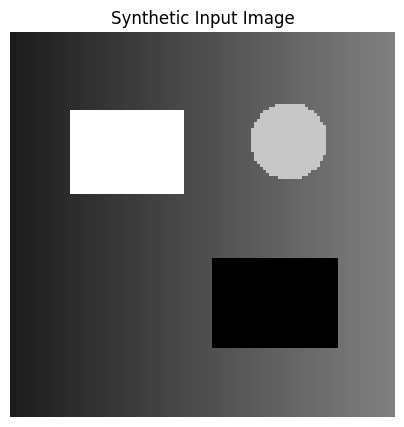

Image shape: (128, 128)


In [32]:
image = create_demo_image(H=128, W=128)
show_image(image, "Synthetic Input Image")
print("Image shape:", image.shape)

### Filter masks
The following $3\times3$ masks are supplied only as **experiment inputs**. They are not implementations of convolution.

- Horizontal/vertical edge masks emphasize intensity transitions.
- Sharpening strengthens the center pixel relative to its neighbors.
- Blurring computes a local average.

In [34]:
vertical_edge = np.array([
    [-1., 0., 1.],
    [-1., 0., 1.],
    [-1., 0., 1.]
])

horizontal_edge = np.array([
    [-1., -1., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  1.,  1.]
])

sharpen = np.array([
    [ 0., -1.,  0.],
    [-1.,  5., -1.],
    [ 0., -1.,  0.]
])

blur = np.ones((3, 3), dtype=float) / 9.0

print("Vertical edge filter:", vertical_edge)
print("Horizontal edge filter:", horizontal_edge)
print("Sharpen filter:", sharpen)
print("Blur filter:", blur)

Vertical edge filter: [[-1.  0.  1.]
 [-1.  0.  1.]
 [-1.  0.  1.]]
Horizontal edge filter: [[-1. -1. -1.]
 [ 0.  0.  0.]
 [ 1.  1.  1.]]
Sharpen filter: [[ 0. -1.  0.]
 [-1.  5. -1.]
 [ 0. -1.  0.]]
Blur filter: [[0.111 0.111 0.111]
 [0.111 0.111 0.111]
 [0.111 0.111 0.111]]


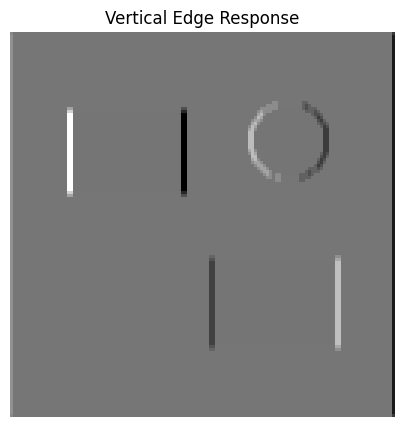

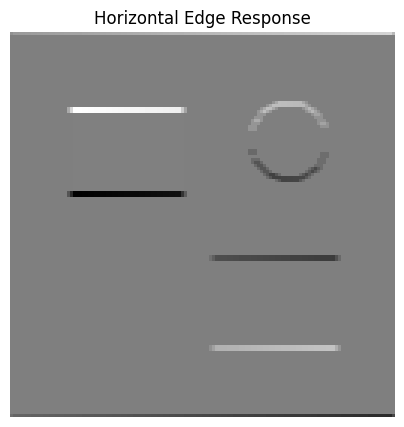

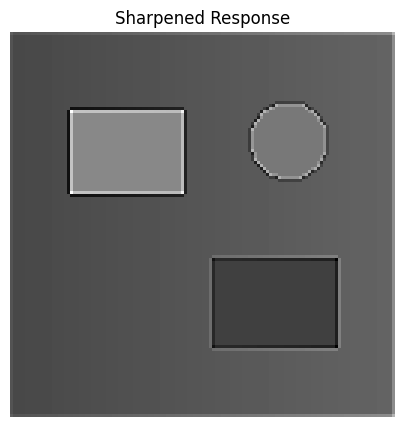

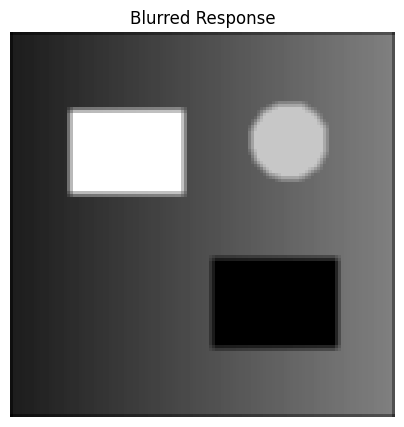

In [35]:
# Apply your conv2d implementation
Z_vertical   = conv2d(image, vertical_edge, stride=1, padding="same")
Z_horizontal = conv2d(image, horizontal_edge, stride=1, padding="same")
Z_sharpen    = conv2d(image, sharpen, stride=1, padding="same")
Z_blur       = conv2d(image, blur, stride=1, padding="same")

show_image(normalize_for_display(Z_vertical), "Vertical Edge Response")
show_image(normalize_for_display(Z_horizontal), "Horizontal Edge Response")
show_image(normalize_for_display(Z_sharpen), "Sharpened Response")
show_image(normalize_for_display(Z_blur), "Blurred Response")

### Observation Task — Filter Response
Complete this table in your lab record.

| Filter | Main visual effect | What image information is emphasized/suppressed? |
|---|---|---|
| Vertical edge |  |  |
| Horizontal edge |  |  |
| Sharpen |  |  |
| Blur |  |  |

### Optional: use your own image
Run the next cell in Colab, upload an image, convert it to grayscale, and then use **your own `conv2d` function** for filtering.

In [36]:
# OPTIONAL COLAB CELL
# Uncomment only when running in Google Colab.
# from google.colab import files
# from PIL import Image
# import io
#
# uploaded = files.upload()
# filename = next(iter(uploaded))
# pil_img = Image.open(io.BytesIO(uploaded[filename])).convert("L")
# user_image = np.asarray(pil_img, dtype=float) / 255.0
# show_image(user_image, "Uploaded Grayscale Image")
#
# user_edges = conv2d(user_image, vertical_edge, stride=1, padding="same")
# show_image(normalize_for_display(user_edges), "Edge Response of Uploaded Image")

<a name="part-g"></a>
# 10 — Part G: Parameter Experiments and Analysis

The purpose of this section is not just to obtain an output; it is to understand how CNN architectural parameters modify the feature map.

## Experiment 1 — Effect of stride $S$
Use the same input image and $3\times3$ edge filter with:

- $S=1$
- $S=2$
- $S=3$

Use explicit padding values if needed. **Predict the output shape before running each case.**

S=1, P=0, output shape=(126, 126)


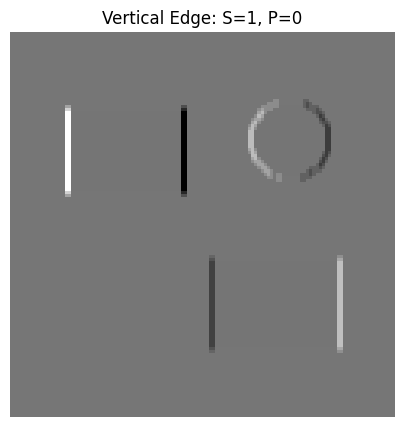

S=2, P=0, output shape=(63, 63)


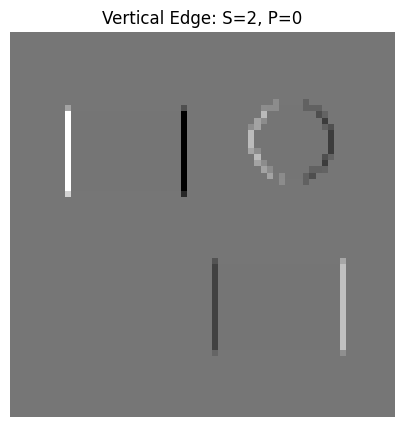

S=3, P=0, output shape=(42, 42)


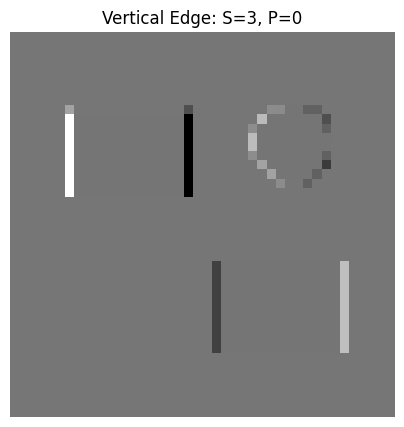

In [37]:
# STUDENT EXPERIMENT: stride
stride_results = {}

for S in [1, 2, 3]:
    # Choose padding deliberately and state your choice.
    P = 0
    Z = conv2d(image, vertical_edge, stride=S, padding=P)
    stride_results[S] = Z
    print(f"S={S}, P={P}, output shape={Z.shape}")
    show_image(normalize_for_display(Z), f"Vertical Edge: S={S}, P={P}")

### Analyze Experiment 1
1. How does increasing $S$ affect spatial resolution?
2. Does a larger stride change the filter values themselves?
3. What information may be missed when $S$ becomes large?

## Experiment 2 — Effect of filter size $F$
Create averaging filters of sizes:

- $3\times3$
- $5\times5$
- $7\times7$

Apply each using `same` padding with $S=1$ (all filters are odd-sized). Compare the amount of smoothing.

F=3, output shape=(128, 128)


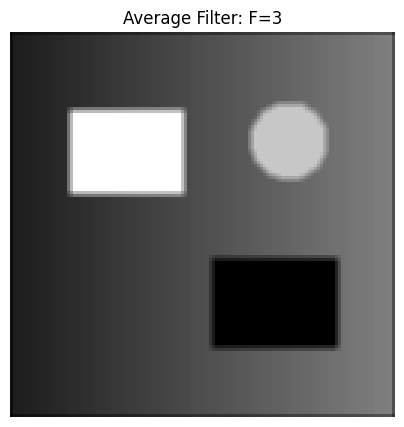

F=5, output shape=(128, 128)


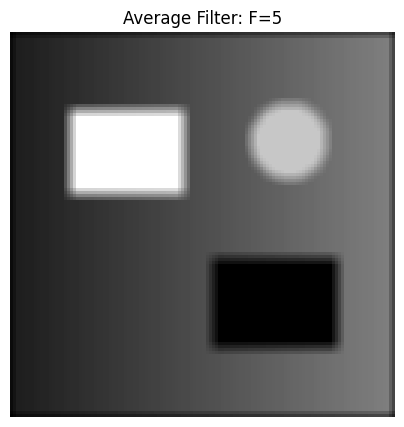

F=7, output shape=(128, 128)


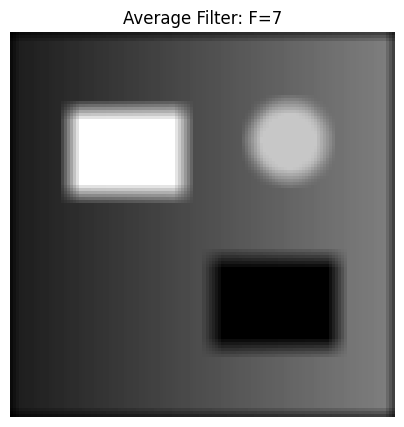

In [38]:
# STUDENT EXPERIMENT: filter size
for F in [3, 5, 7]:
    filter_mask = np.ones((F, F), dtype=float) / (F * F)
    Z = conv2d(image, filter_mask, stride=1, padding="same")
    print(f"F={F}, output shape={Z.shape}")
    show_image(normalize_for_display(Z), f"Average Filter: F={F}")

### Analyze Experiment 2
1. Why does a larger averaging filter produce stronger blur?
2. What happens to fine details?
3. Why does `same` padding keep the displayed image dimensions unchanged here?

## Experiment 3 — Pooling on a feature volume
Construct a small filter bank with multiple filters, run `conv_forward`, apply ReLU, and compare max versus average pooling.

Input: H x W x C = 128 x 128 x 1
After convolution: H x W x C = 128 x 128 x 4
After ReLU: H x W x C = 128 x 128 x 4
After max pooling: H x W x C = 64 x 64 x 4
After average pooling: H x W x C = 64 x 64 x 4


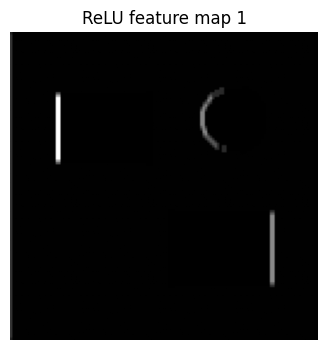

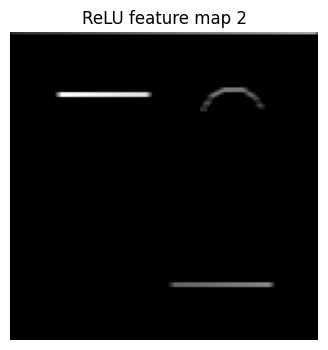

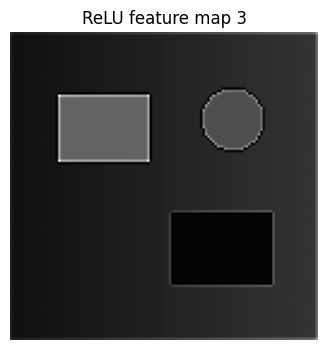

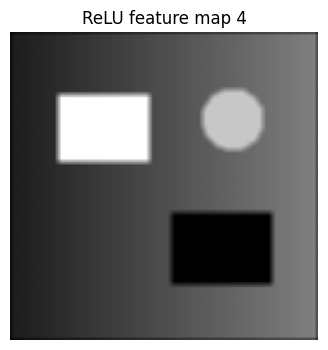

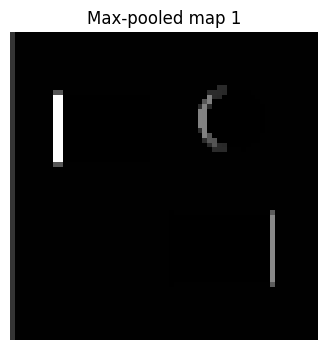

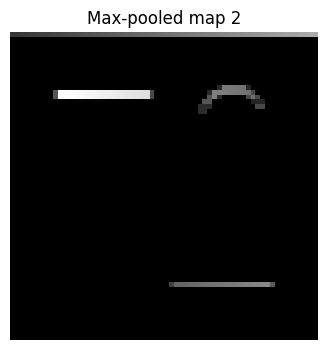

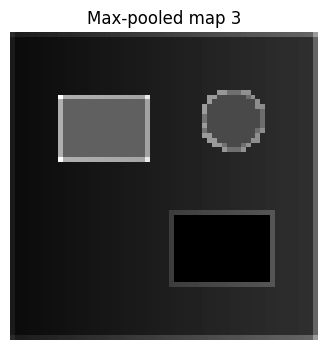

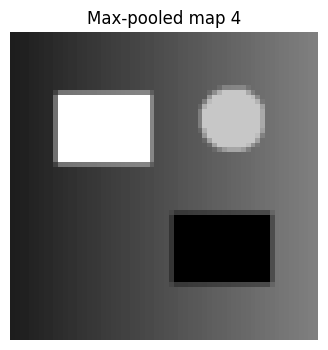

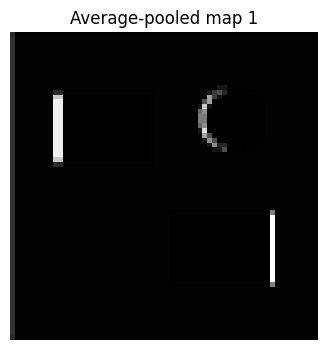

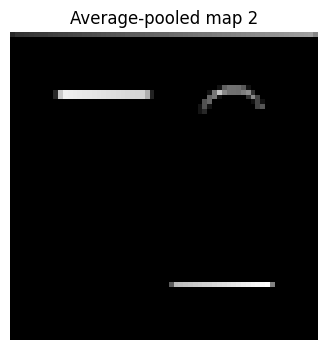

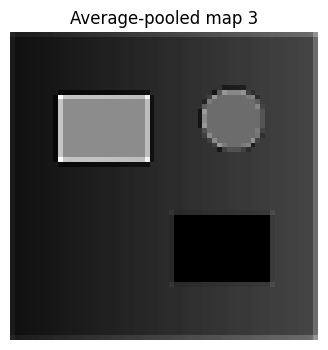

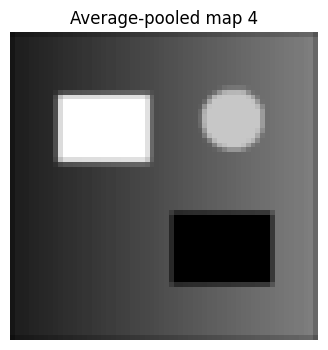

In [39]:
# Convert grayscale image to H x W x C_in, where C_in=1
A_img = image[:, :, None]

# F=3, C_in=1, K=4
filters_demo = np.stack([
    vertical_edge,
    horizontal_edge,
    sharpen,
    blur
], axis=-1)[:, :, None, :]

Z_demo = conv_forward(A_img, filters_demo, stride=1, padding="same")
A_demo = np.maximum(0, Z_demo)
A_max_demo = pool_forward(A_demo, pool_size=2, stride=2, mode="max")
A_avg_demo = pool_forward(A_demo, pool_size=2, stride=2, mode="average")

print_volume_shape("Input", A_img)
print_volume_shape("After convolution", Z_demo)
print_volume_shape("After ReLU", A_demo)
print_volume_shape("After max pooling", A_max_demo)
print_volume_shape("After average pooling", A_avg_demo)

show_feature_volume(A_demo, title_prefix="ReLU feature map")
show_feature_volume(A_max_demo, title_prefix="Max-pooled map")
show_feature_volume(A_avg_demo, title_prefix="Average-pooled map")

### Analyze Experiment 3
1. Why is $C_{\mathrm{out}}=4$ after convolution?
2. Why does pooling keep the same number of channels?
3. Which pooling operation preserves the strongest local activation?
4. Which pooling operation gives a smoother summary?
5. What information is lost after pooling?

## Observation Table — Dimension Verification
Record at least five configurations.

| $H_{\mathrm{in}}\times W_{\mathrm{in}}\times C_{\mathrm{in}}$ | $F$ | $P$ | $S$ | $K$ | Calculated output | Obtained output | Match? |
|---|---:|---:|---:|---:|---|---|---|
|  |  |  |  |  |  |  |  |
|  |  |  |  |  |  |  |  |
|  |  |  |  |  |  |  |  |
|  |  |  |  |  |  |  |  |
|  |  |  |  |  |  |  |  |

## Analysis Questions
Answer these in your submission.

1. Manually compute the first output value of the basic 2D convolution example and verify it with your code.
2. Derive the output-dimension expression for convolution with $F$, $P$, and $S$.
3. Differentiate `valid` and `same` padding.
4. Why must a filter in a CNN span all $C_{\mathrm{in}}$ input channels?
5. For an RGB input $64\times64\times3$ and $K=16$ filters of size $3\times3\times3$, with $P=1$ and $S=1$, determine the output dimensions.
6. Explain how $S$ affects output size and information density.
7. Why does $C_{\mathrm{out}}=K$ after convolution?
8. Differentiate max pooling and average pooling based on your observed results.
9. Why does pooling normally preserve the number of channels?
10. Why is ReLU commonly placed after convolution and before pooling?
11. What spatial information is lost by pooling, and why can pooling still be useful?
12. Why do larger averaging filters create stronger smoothing?

<a name="final-test"></a>
# 11 — Final Public-Test Check
Run this only after completing **all six exercises**.

In [40]:
run_all_tests(globals())

✓ conv2d_basic: All tests passed.
✓ zero_pad: All tests passed.
✓ conv2d: All tests passed.
✓ conv_forward: All tests passed.
✓ pool_forward: All tests passed.
✓ conv_pool_block: All tests passed.

All Lab-06 public tests passed successfully!


## Common Debugging Checklist
If a test fails, check these items before changing multiple parts of your code:

- **Wrong shape:** re-check the $H_{\mathrm{out}}$, $W_{\mathrm{out}}$ formula.
- **Wrong values but correct shape:** inspect window start indices and element-wise multiplication.
- **Stride error:** window starts should depend on `h * stride` and `w * stride`.
- **Padding error:** pad height and width, but not the channel axis.
- **Multi-channel convolution error:** sum over $F\times F\times C_{\mathrm{in}}$ for each filter.
- **Wrong output depth:** output channel count must equal $K$.
- **Pooling error:** pool each channel independently.
- **Combined block error:** order must be convolution → ReLU → pooling.

<a name="submission"></a>
# 12 — Submission Requirements

Submit the completed notebook after ensuring that:

- all six student functions are implemented from scratch;
- all public tests pass;
- manual output-dimension calculations are included;
- edge, sharpen, and blur feature maps are displayed;
- stride and filter-size experiments are completed;
- max and average pooling are compared;
- analysis questions are answered in your own words; and
- the final cell shows that all Lab-06 public tests pass.

### Functions to be completed
```python
conv2d_basic(...)
zero_pad(...)
conv2d(...)
conv_forward(...)
pool_forward(...)
conv_pool_block(...)
```

---

## Result
Two-dimensional convolution is implemented from scratch and generalized to support zero padding, variable stride, multi-channel input volumes, and multiple filters. Max and average pooling are implemented independently, and convolution, ReLU, and pooling are combined into a simple CNN feature-extraction block. The influence of filter type, filter size, padding, stride, and pooling on output feature maps is then analyzed experimentally.